# Relatório Lab 4 — Parte B: Filtragem Espacial Passa-Alta

**Autores:**  
Allan Hirose Pires de Souza  
Juliana dos Santos Silva  
Kaike Nascimento Souza  
**Data de realização dos experimentos:** Março de 2026  
**Data de publicação do relatório:** 10 de Março de 2026  

---

## 1. Introdução

Nesta parte do Lab 4 trabalhamos com filtros passa-alta, que realçam bordas e detalhes finos nas imagens.

Técnicas estudadas:
- Filtro Laplaciano
- Filtro Sobel
- Realce por Laplaciano
- Máscara Unsharp / Highboost
- Detector de Bordas Canny

---

## 2. Procedimentos Experimentais

- Imagens: foto individual e do grupo (Lab3), convertidas para escala de cinza
- Sobel testado com ksize 3 e 5
- Highboost testado com k = 1.0, 1.5 e 3.0
- Canny testado com thresholds 50/150

Imagem individual shape: (470, 1538)


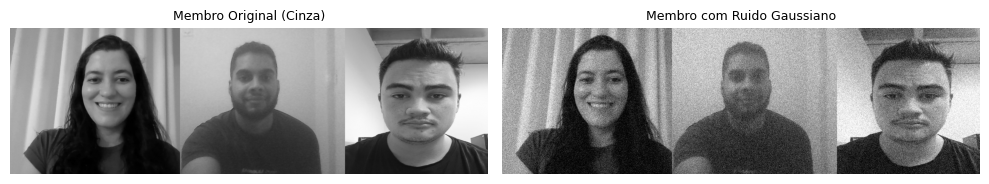

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import warnings
warnings.filterwarnings('ignore')

def plot_images(images, titles, rows=1, cols=None, figsize=(16, 5), cmap='gray'):
    if cols is None:
        cols = len(images)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

img_membro_bgr = cv2.imread('../Lab3/imagem.jpeg')
img_grupo_bgr  = cv2.imread('../Lab3/imagem.jpeg')

if img_membro_bgr is None:
    print("[AVISO] imagem.jpeg nao encontrada — usando placeholder")
    img_membro_bgr = np.random.randint(50, 200, (400, 400, 3), dtype=np.uint8)
if img_grupo_bgr is None:
    img_grupo_bgr = img_membro_bgr.copy()

img_membro     = cv2.cvtColor(img_membro_bgr, cv2.COLOR_BGR2GRAY)
img_grupo_gray = cv2.cvtColor(img_grupo_bgr,  cv2.COLOR_BGR2GRAY)
img_grupo_rgb  = cv2.cvtColor(img_grupo_bgr,  cv2.COLOR_BGR2RGB)

def adicionar_ruido_gaussiano(imagem, media=0, std=30):
    ruido = np.random.normal(media, std, imagem.shape).astype('float32')
    return np.clip(imagem.astype('float32') + ruido, 0, 255).astype('uint8')

img_membro_ruidosa = adicionar_ruido_gaussiano(img_membro)
img_grupo_ruidosa  = adicionar_ruido_gaussiano(img_grupo_gray)

print(f"Imagem individual shape: {img_membro.shape}")
plot_images([img_membro, img_membro_ruidosa],
            ['Membro Original (Cinza)', 'Membro com Ruido Gaussiano'],
            figsize=(10, 5))

## 3. Item (a): Laplaciano e Sobel

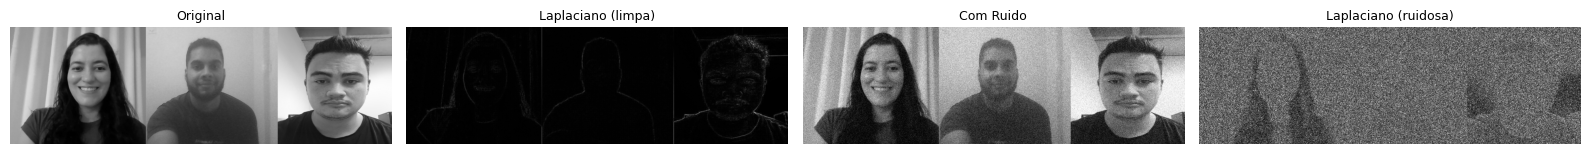

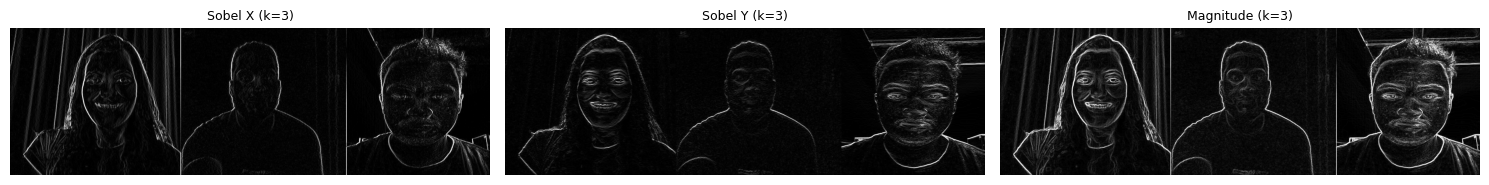

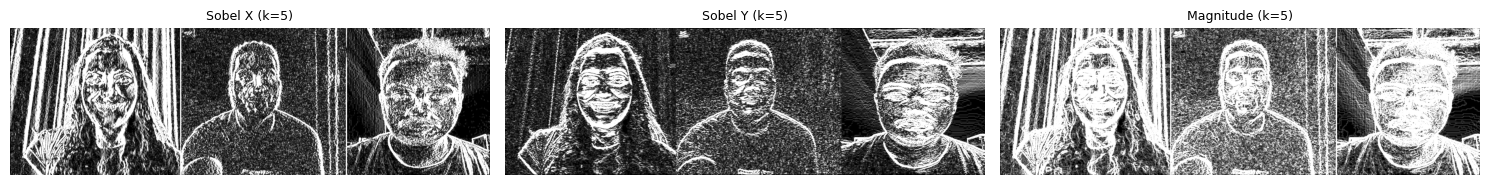

In [7]:
laplaciano      = cv2.Laplacian(img_membro, cv2.CV_64F)
laplaciano_abs  = cv2.convertScaleAbs(laplaciano)

laplaciano_ruido     = cv2.Laplacian(img_membro_ruidosa, cv2.CV_64F)
laplaciano_ruido_abs = cv2.convertScaleAbs(laplaciano_ruido)

plot_images(
    [img_membro, laplaciano_abs, img_membro_ruidosa, laplaciano_ruido_abs],
    ['Original', 'Laplaciano (limpa)', 'Com Ruido', 'Laplaciano (ruidosa)'],
    figsize=(16, 5)
)

for ksize in [3, 5]:
    sox = cv2.Sobel(img_membro, cv2.CV_64F, 1, 0, ksize=ksize)
    soy = cv2.Sobel(img_membro, cv2.CV_64F, 0, 1, ksize=ksize)
    mag = cv2.convertScaleAbs(np.abs(sox) + np.abs(soy))
    plot_images(
        [cv2.convertScaleAbs(sox), cv2.convertScaleAbs(soy), mag],
        [f'Sobel X (k={ksize})', f'Sobel Y (k={ksize})', f'Magnitude (k={ksize})'],
        figsize=(15, 5)
    )

**Observações:**

- O Laplaciano detecta bordas em todas as direções, mas é muito sensível a ruído.
- Sobel k=3 tem boa precisão em bordas finas; k=5 gera bordas mais espessas e é um pouco mais robusto.
- Sobel-X destaca bordas verticais e Sobel-Y as horizontais.

## 4. Item (b.1): Realce por Laplaciano

Aplicamos g(x,y) = f(x,y) + c · ∇²f(x,y) com c = -1, na imagem limpa e na ruidosa.

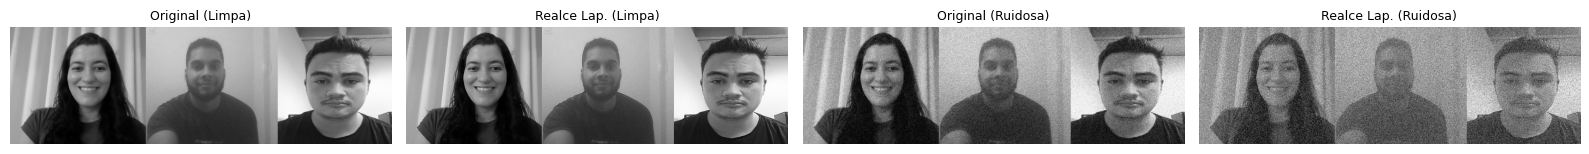

In [8]:
def realce_laplaciano(imagem, c=-1):
    lap = cv2.Laplacian(imagem, cv2.CV_64F)
    realcada = np.clip(imagem.astype('float64') + c * lap, 0, 255).astype('uint8')
    return realcada

realce_limpa = realce_laplaciano(img_grupo_gray, c=-1)
realce_ruido = realce_laplaciano(img_grupo_ruidosa, c=-1)

plot_images(
    [img_grupo_gray, realce_limpa, img_grupo_ruidosa, realce_ruido],
    ['Original (Limpa)', 'Realce Lap. (Limpa)', 'Original (Ruidosa)', 'Realce Lap. (Ruidosa)'],
    figsize=(16, 5)
)

**Observações:**

- Na imagem limpa o realce funcionou bem, as bordas ficaram mais nítidas.
- Na imagem ruidosa o resultado ficou ruim, pois o Laplaciano amplificou o ruído junto com as bordas.

## 5. Item (b.2): Highboost Filtering

Testamos com k = 1.0 (unsharp masking padrão), k = 1.5 e k = 3.0.

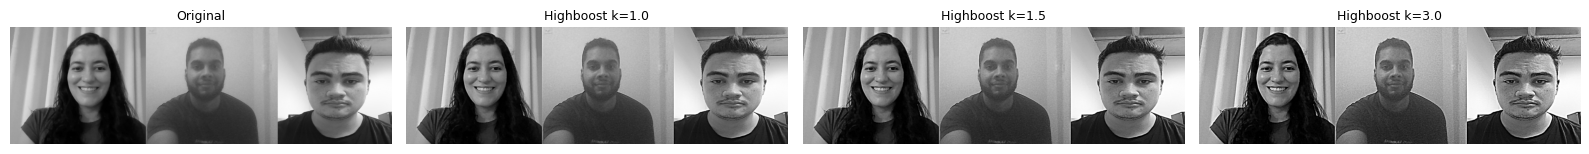

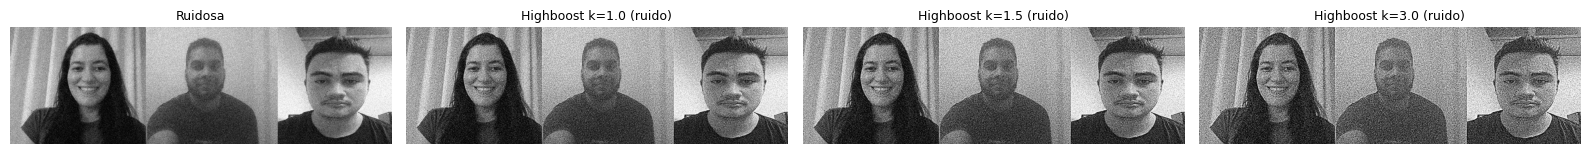

In [9]:
def highboost(imagem, k=1.5, sigma=3):
    borrada  = cv2.GaussianBlur(imagem, (0, 0), sigma)
    mascara  = imagem.astype('float64') - borrada.astype('float64')
    realcada = np.clip(imagem.astype('float64') + k * mascara, 0, 255).astype('uint8')
    return realcada

ks = [1.0, 1.5, 3.0]
imgs_hb = [img_grupo_gray] + [highboost(img_grupo_gray, k=ki) for ki in ks]
titulos  = ['Original'] + [f'Highboost k={ki}' for ki in ks]
plot_images(imgs_hb, titulos, figsize=(16, 5))

imgs_hb_ruido = [img_grupo_ruidosa] + [highboost(img_grupo_ruidosa, k=ki) for ki in ks]
titulos_ruido = ['Ruidosa'] + [f'Highboost k={ki} (ruido)' for ki in ks]
plot_images(imgs_hb_ruido, titulos_ruido, figsize=(16, 5))

**Observações:**

- k=1.0 dá um realce suave e natural.
- k=1.5 tem bom equilíbrio entre nitidez e aparência.
- k=3.0 realça demais e começa a gerar halos nas bordas.
- Com ruído, o highboost amplifica o ruído mas menos que o Laplaciano direto.

## 6. Desafio: Detector de Bordas Canny

Comparamos o Canny com o Sobel na imagem limpa e na ruidosa.

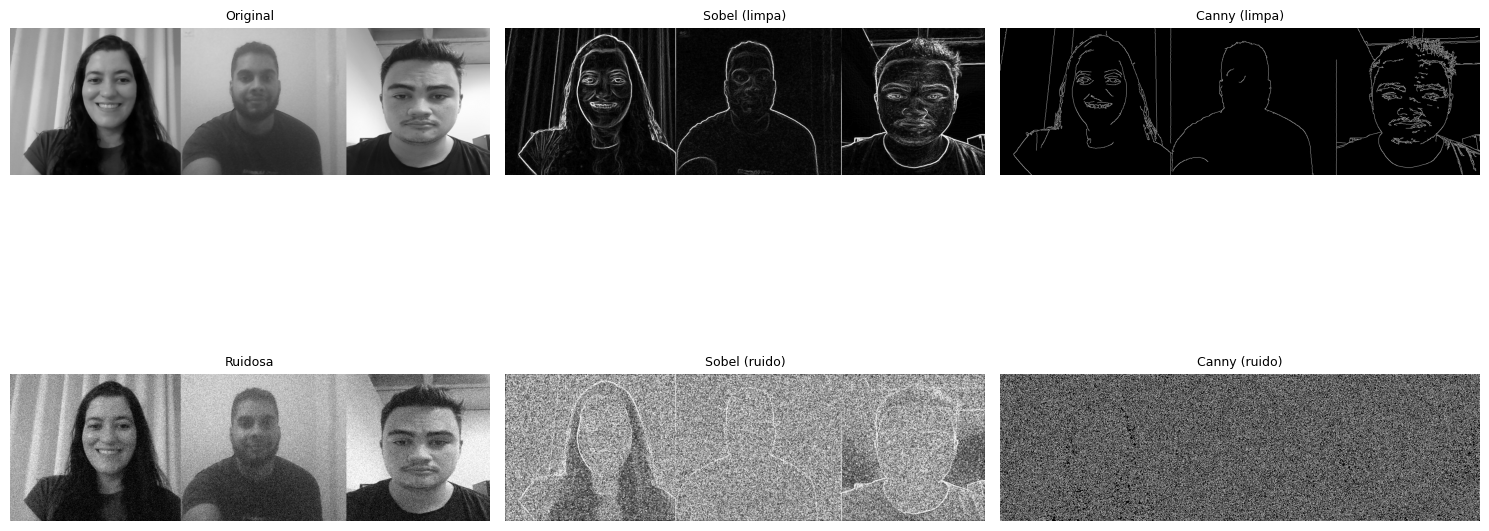

In [10]:
canny_limpa = cv2.Canny(img_membro, threshold1=50, threshold2=150)
canny_ruido = cv2.Canny(img_membro_ruidosa, threshold1=50, threshold2=150)

sox   = cv2.Sobel(img_membro, cv2.CV_64F, 1, 0, ksize=3)
soy   = cv2.Sobel(img_membro, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.convertScaleAbs(np.abs(sox) + np.abs(soy))

sox_r = cv2.Sobel(img_membro_ruidosa, cv2.CV_64F, 1, 0, ksize=3)
soy_r = cv2.Sobel(img_membro_ruidosa, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag_r = cv2.convertScaleAbs(np.abs(sox_r) + np.abs(soy_r))

plot_images(
    [img_membro,          sobel_mag,     canny_limpa,
     img_membro_ruidosa,  sobel_mag_r,   canny_ruido],
    ['Original',          'Sobel (limpa)', 'Canny (limpa)',
     'Ruidosa',           'Sobel (ruido)', 'Canny (ruido)'],
    rows=2, cols=3, figsize=(15, 9)
)

## 7. Análise e Discussão

- O Canny produz bordas mais limpas que o Sobel, com 1 pixel de espessura.
- Na imagem ruidosa, o Canny é mais robusto por fazer suavização interna antes de detectar bordas. O Sobel gera muitos falsos positivos.

---

## 8. Conclusões

- O Laplaciano é bom para bordas omnidirecionais mas sensível a ruído.
- O Sobel é mais robusto e dá informação direcional.
- O realce por Laplaciano funciona bem em imagens limpas mas amplifica ruído.
- O Highboost é uma alternativa mais equilibrada para realce.
- O Canny é o melhor detector de bordas testado.

---

## Referências

- Gonzalez, R. C.; Woods, R. E. *Digital Image Processing*, 4th ed.
- OpenCV Tutorials: [Image Gradients](https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html)
- OpenCV Tutorials: [Canny Edge Detection](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html)